<a href="https://colab.research.google.com/github/ernesto10loera-star/Actividades-IAyRN/blob/main/AF6_Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset cargado exitosamente.
Características: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']... (total 30)
Set de entrenamiento: 455 muestras
Set de prueba: 114 muestras
El modelo de árbol de decisión ha sido entrenado.

--- Matriz de Confusión ---
[[40  3]
 [ 3 68]]

Precisión (Accuracy): 0.9474

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

   malignant       0.93      0.93      0.93        43
      benign       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



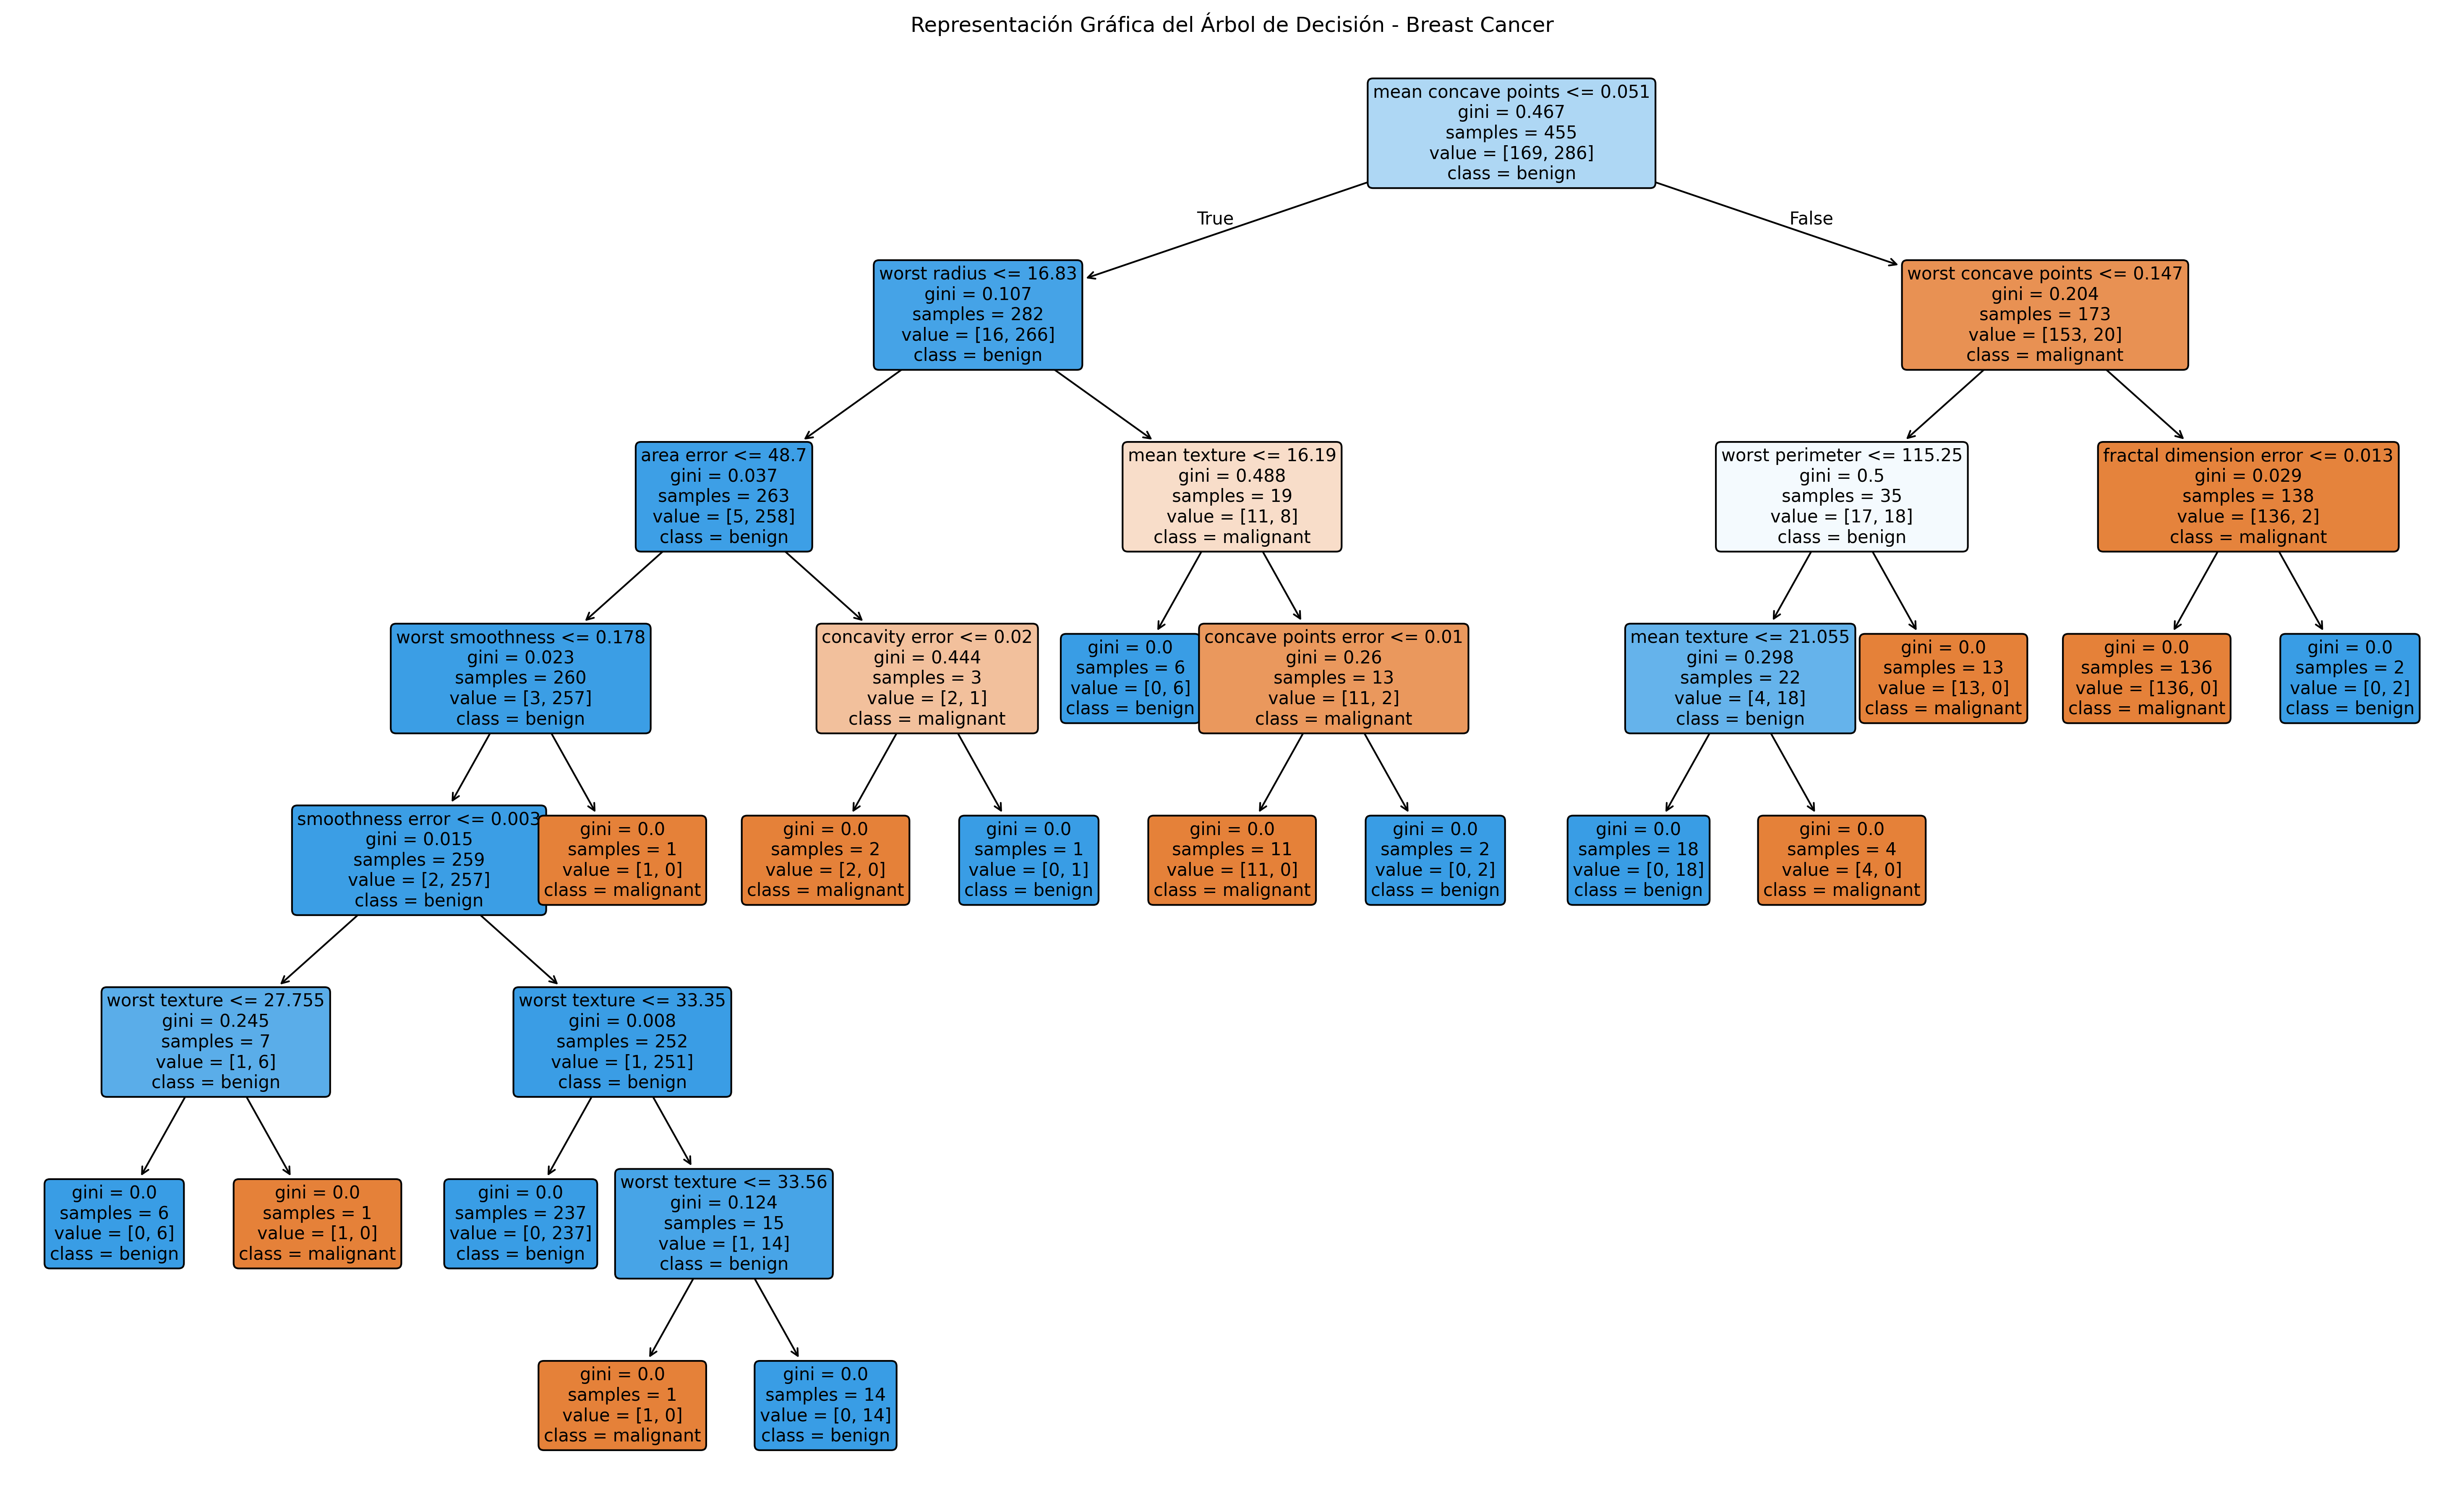

In [ ]:
# AF 6: Aprendizaje supervisado, árbol de decisión. Ernesto Gerardo Loera Vega 2101664 V6
# 1. Cargar librerías
# =================================================================
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

# =================================================================
# 2. Cargar datos
# =================================================================
# Cargamos el dataset desde la biblioteca scikit-learn
datos_cancer = load_breast_cancer()

# Separamos las características (X) y el diagnóstico (y)
X = datos_cancer.data
y = datos_cancer.target

print("Dataset cargado exitosamente.")
print(f"Características: {datos_cancer.feature_names[:5]}... (total {len(datos_cancer.feature_names)})")

# =================================================================
# 3. Preprocesamiento de datos
# =================================================================
# Usamos train_test_split con los nombres de variables solicitados
# Proporción: 80% entrenamiento, 20% prueba
train_data, test_data, train_labels, test_labels = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Set de entrenamiento: {len(train_data)} muestras")
print(f"Set de prueba: {len(test_data)} muestras")

# =================================================================
# 4. Selección y entrenamiento del modelo
# =================================================================
# Instanciamos el árbol de decisión
modelo_arbol = DecisionTreeClassifier(random_state=42)

# Entrenamos con la función fit usando los datos de entrenamiento
modelo_arbol.fit(train_data, train_labels)

print("El modelo de árbol de decisión ha sido entrenado.")

# =================================================================
# 5. Prueba del modelo
# =================================================================
# Realizamos predicciones con el conjunto de prueba (test_data)
predicciones = modelo_arbol.predict(test_data)

# Obtener matriz de confusión
print("\n--- Matriz de Confusión ---")
print(confusion_matrix(test_labels, predicciones))

# Calcular la precisión (accuracy)
precision = accuracy_score(test_labels, predicciones)
print(f"\nPrecisión (Accuracy): {precision:.4f}")

# Mostrar el reporte de clasificación (classification_report)
print("\n--- Reporte de Clasificación ---")
print(classification_report(test_labels, predicciones, target_names=datos_cancer.target_names))

# Visualización gráfica del árbol con DPI = 300
plt.figure(figsize=(25, 15), dpi=300)
plot_tree(
    modelo_arbol,
    feature_names=datos_cancer.feature_names,
    class_names=datos_cancer.target_names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Representación Gráfica del Árbol de Decisión - Breast Cancer")
plt.show()